In [ ]:
!pip install sentence-transformers

In [ ]:
sentences = [
    # Cricket (3)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",

    # Cooking (3)
    "Cooking pasta requires boiling water",
    "Baking a cake needs precise measurements",
    "Frying vegetables enhances flavor",

    # Cybersecurity (4)
    "Cybersecurity protects systems from attacks",
    "Strong passwords prevent hacking",
    "Encryption secures communication",
    "Firewalls block unauthorized access"
]

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


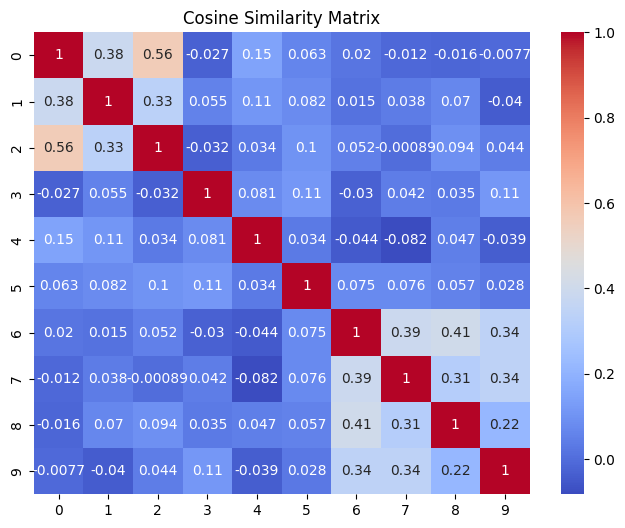

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]


In [ ]:
import numpy as np

top_indices = np.argsort(similarities)[-2:][::-1]

print("Top 2 similar sentences:\n")
for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")


Top 2 similar sentences:

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5414

